In [1]:
# Importing required packages
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from numpy.polynomial import Polynomial
from matplotlib.gridspec import GridSpec

In [2]:
# Appending the current working directory to the system path of python
curr_path=os.getcwd()
sys.path.append(curr_path)

#################################################################################################
## Geometrical Brownian Motion for variable operating costs

In [3]:
op_cost = 5
op_cost_rate = 0.02

p0_VOC = op_cost
mu_GBM_VOC = op_cost_rate
sigma_GBM_VOC = 0.10

In [4]:
trialno = 10000
T = 10
dt = 1/5                       # granularity of time-period 
time = np.arange(dt, T+dt, dt)  # time points
N = len(time)                   # number of time intervals
N

50

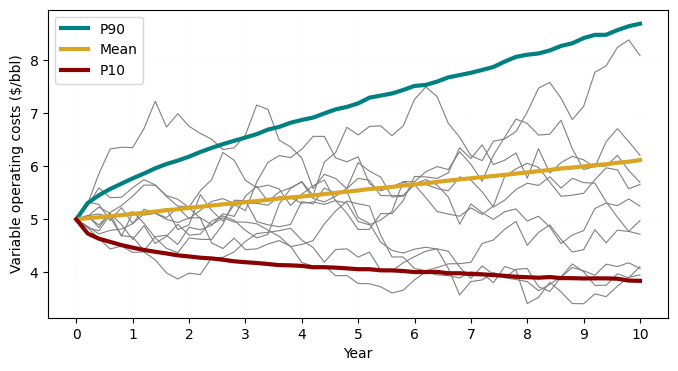

In [5]:
%run GBM_function.ipynb  # operating costs paths

#################################################################################################
## Two-factor model for oil prices

In [6]:
%run parameters_kalman_filter.ipynb # calcula via filtro de Kalman os 7 parâmetros do modelo de dois fatores

Optimization terminated successfully    (Exit mode 0)
            Current function value: -14503.574174939424
            Iterations: 27
            Function evaluations: 387
            Gradient evaluations: 23


In [7]:
pd.DataFrame(param_df)

,Parameters,initial,optimized
0,kappa,1.00,3.771950
1,sigma_chi,0.01,0.287692
2,risk_chi,0.01,-0.202457
3,mu_xi,0.01,-0.161038
4,sigma_xi,0.01,0.222824
5,risk_xi,0.01,-0.092241
6,rho,0.10,0.398284
7,chi0,0.28,0.049572
8,xi0,3.50,4.207751


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


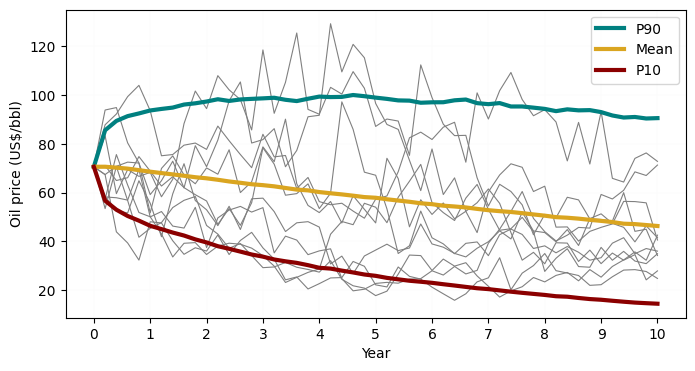

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


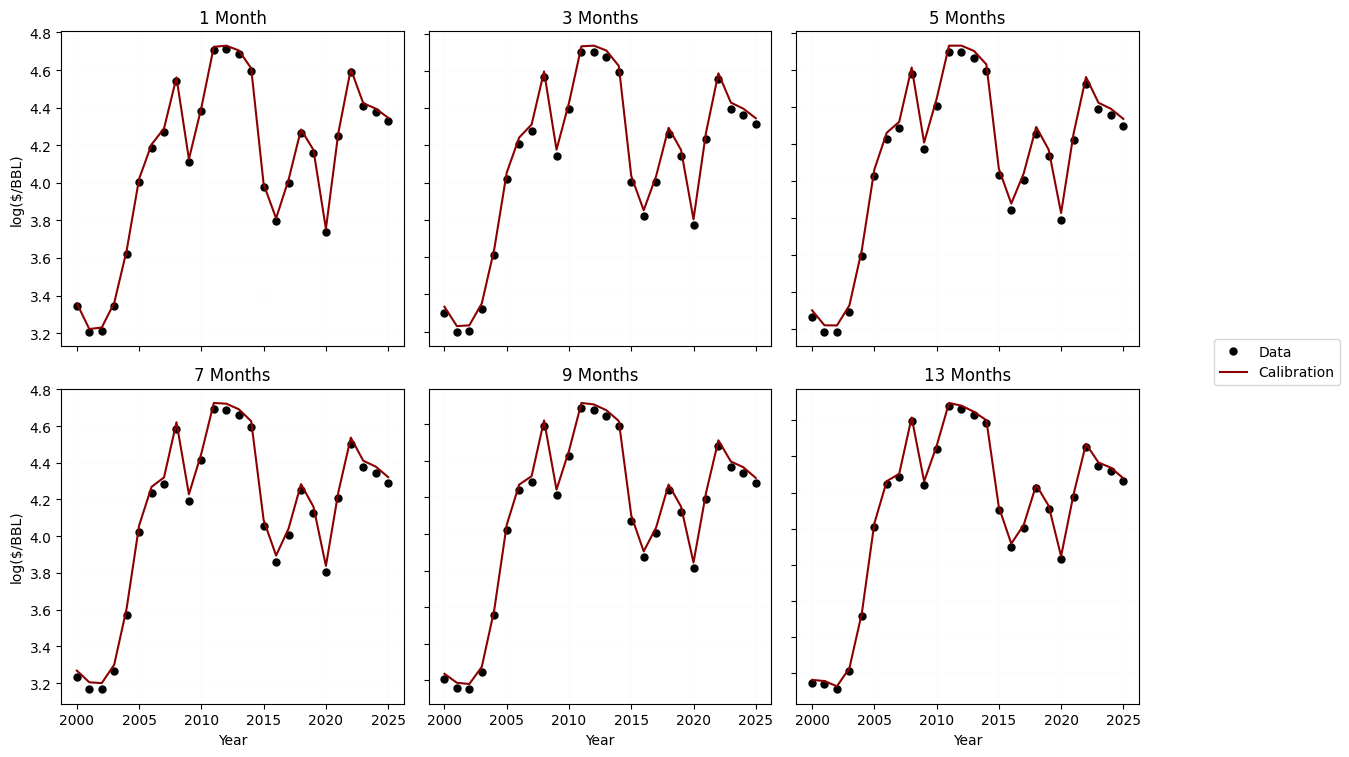

In [8]:
%run parameters_SS.ipynb # plota os gráficos de OIL_PRICE e CALIBRATION (e salva as figuras pro paper)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


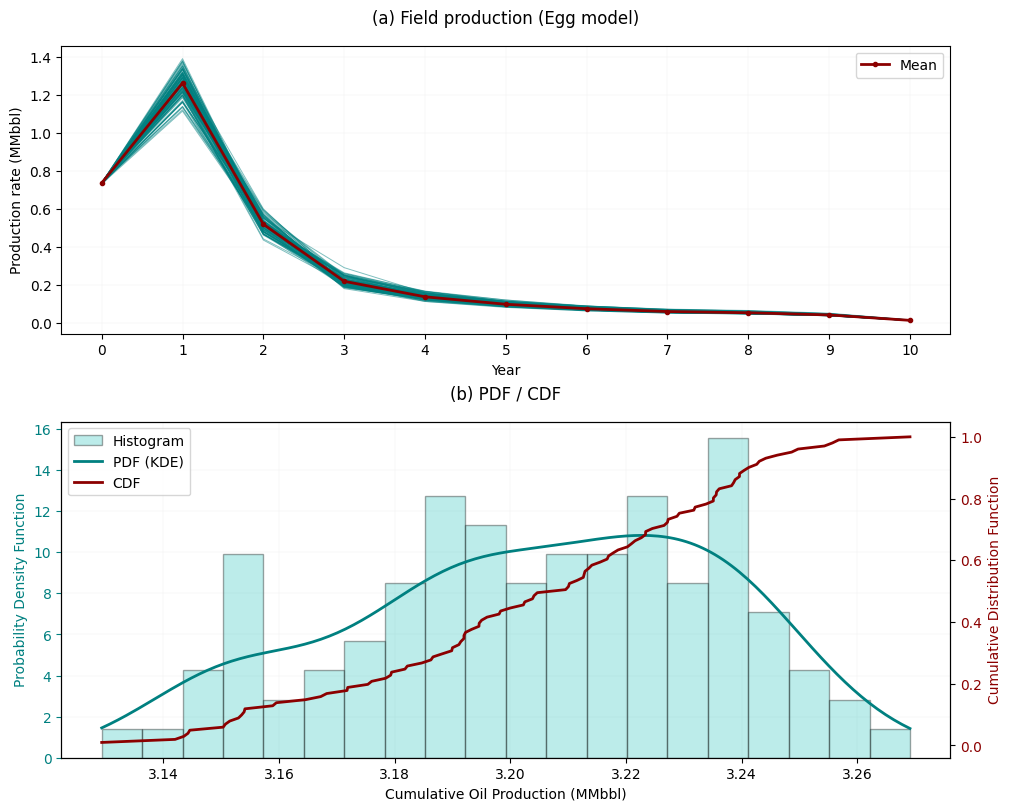

In [9]:
%run producao_campo_4_PRODs.ipynb # field production / PDF / CDF / EGG MODEL

## Oil price (10.000, 11)

In [10]:
# After you computed chi, xi, t, T, dt
prices = np.exp(chi + xi)  # shape: (trialno, n_time)

# Indices for integer years (robust to float rounding)
years_int = np.arange(0, int(round(T)) + 1, 1)         # [0,1,2,...,T]
idx = np.array([np.argmin(np.abs(t - y)) for y in years_int])

# Time vector exactly at those indices (should be [0,1,...,T])
t_int = t[idx]

# All simulated prices at integer years (keep for later use)
prices_int_all = prices[:, idx]                         # shape: (trialno, len(years_int))

# If you need summary bands at the same times:
mean_price_int = prices_int_all.mean(axis=0)

#################################################################################################
## Table Egg Model

In [11]:
# BDH problema
period = T

fixed_cost = 0.3
profit = 0.25
dr = 0.05  # BDH = 0.1 Ahmandi&Bratvold = 0.05 (used risk-neutral valuation approach)
init_invest = 20

In [21]:
%run my_table.ipynb  # contém a função table_()

frame, market_val, NPV = table(period, mean_curve, op_cost, op_cost_rate, mean_price_int, fixed_cost, profit, dr, init_invest)

In [22]:
frame

,0,1,2,3,4,5,6,7,8,9,10
Production level,0.736,1.262,0.518,0.218,0.136,0.097,0.073,0.059,0.052,0.041,0.012
Variable op cost rate,5.00,5.10,5.20,5.31,5.41,5.52,5.63,5.74,5.86,5.98,6.09
Oil price,70.62,68.61,65.89,63.08,60.25,57.91,55.27,52.81,50.56,48.43,46.33
Revenues,51.95,86.61,34.16,13.74,8.20,5.61,4.06,3.09,2.63,1.97,0.56
Production cost,3.98,6.74,3.00,1.46,1.04,0.83,0.71,0.64,0.61,0.54,0.37
Cash flow,47.97,79.88,31.16,12.29,7.17,4.77,3.34,2.46,2.03,1.43,0.19
Profit sharing,11.99,19.97,7.79,3.07,1.79,1.19,0.84,0.61,0.51,0.36,0.05
Net cash flows,35.98,59.91,23.37,9.21,5.37,3.58,2.51,1.84,1.52,1.07,0.14
PV of cash flows,134.41,103.35,45.61,23.35,14.84,9.94,6.68,4.38,2.67,1.20,0.14


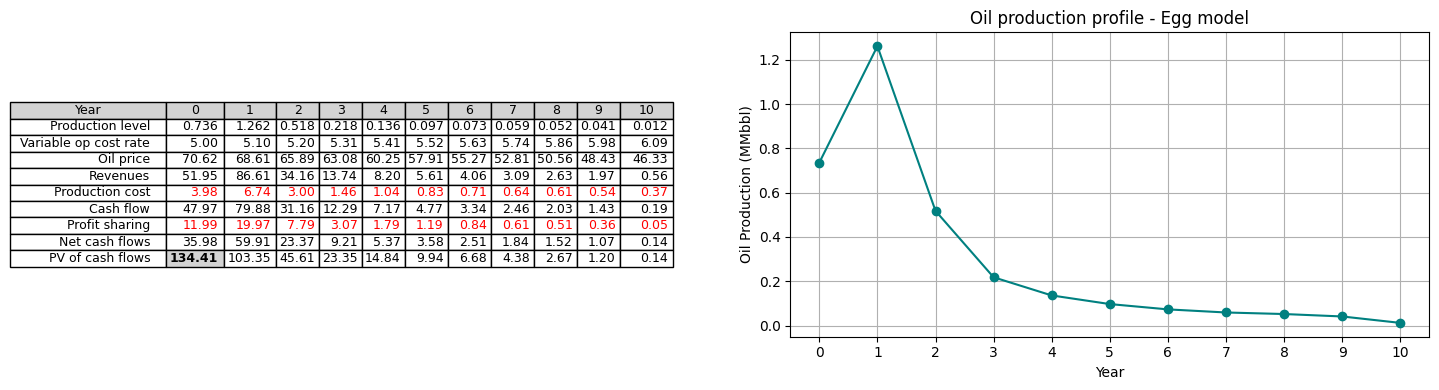

Value of the initial investment: $20.00
PV of cash flows: $134.41
Net Present Value: $114.41


In [23]:
%run plot_table.ipynb

## VOC price (10.000, 11)

In [24]:
# VOC_price tem shape: (trialno, n_time), ex.: (10000, 51)

# Selecionar apenas os tempos inteiros (usando os mesmos índices já calculados)
VOC_price_int_all = VOC_price[:, idx]  # shape: (10000, 11)

# Se precisar da média ao longo das simulações
mean_VOC_price_int = VOC_price_int_all.mean(axis=0)

#################################################################################################
## Cash Flow

In [25]:
N = 10

In [26]:
# CASH FLOW
%run cash_flow.ipynb

                   0          1          2          3          4         5  \
Path 1      35.99761  40.270893  11.658386   5.038027   1.582856   1.01695   
Path 2      35.99761  58.564446  34.261205  18.284487   8.553239  5.717121   
Path 3      35.99761  42.650531  12.530943   7.782254   2.958959  1.097107   
0                ...        ...        ...        ...        ...       ...   
Path 9998   35.99761  37.284093  12.317501   7.952587   2.878469   2.69686   
Path 9999   35.99761  79.895215   37.50174   13.20221   5.278918    3.5367   
Path 10000  35.99761  65.118076  35.115921  13.052634  10.785692  5.042826   

                   6         7         8         9        10  
Path 1       0.65426  0.639487  0.963862  0.337455 -0.040244  
Path 2      4.846122  1.898143  1.512662  1.071752  0.029176  
Path 3      1.036729  1.293375  1.256848  1.374193  0.358829  
0                ...       ...       ...       ...       ...  
Path 9998   1.310359  0.742509  0.494411   0.20308 -0.041237

#################################################################################################
## Value of the project without options

In [27]:
%run present_value.ipynb

Value of the initial investment: $20.00
PV of cash flows: $134.38
Value of the project without options (NPV): $114.38


#################################################################################################
## Value of the project with options

In [28]:
# LSM approach (regression used)
degree = 2
poly_type = 'laguerre'  # poly_type (str): Type of polynomial ('poly', 'hermite', 'legendre', 'chebyshev', 'jacobi', 'laguerre').

# years to exercise options on a list
option_times = [5]
# The list of options must be written in the form of a dictionary with option label as the key, and option expense and cash flow reward as the value.
options = {'continue': [0, 0], 'buyout': [1, 25], 'divest': [0, 2.5]}

%run apply_options.ipynb

Options times:   0%|          | 0/1 [00:00<?, ?time/s]

Value of the initial investment: $20.0
PV of cash flows: $135.4
Value of the project with options (NPV): $115.4
Option value: $1.0


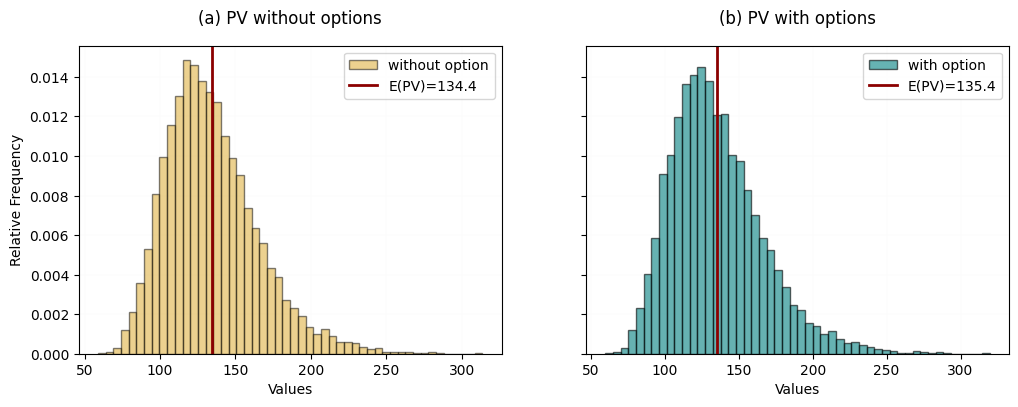

In [30]:
import numpy as np  # Certifique-se de importar numpy
import matplotlib.pyplot as plt

def plot_density_and_frequency(s1, s2, bins=50):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    # Sem opção
    axes[0].set_axisbelow(True)
    axes[0].hist(s1, bins=bins, density=True, color='goldenrod', alpha=0.5, edgecolor='black', label="without option")
    axes[0].axvline(x=np.mean(s1), color='darkred', linestyle='-', lw=2, label=f'E(PV)={np.mean(s1):.1f}')
    axes[0].set_xlabel("Values")
    axes[0].set_ylabel("Relative Frequency")
    #axes[0].set_xlim([0, 1650])
    #axes[0].set_ylim(0, 0.0030)
    axes[0].legend()
    axes[0].grid(lw=0.1, color="0.94")
    # Subtítulo
    #axes[0].text(0.5, -0.25, "(a) PV without options", ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title("(a) PV without options", loc='center', fontsize=12, pad=16)

    # Com opção
    axes[1].set_axisbelow(True)
    axes[1].hist(s2, bins=bins, density=True, color='teal', alpha=0.6, edgecolor='black', label="with option")
    axes[1].axvline(x=np.mean(s2), color='darkred', linestyle='-', lw=2, label=f'E(PV)={np.mean(s2):.1f}')
    axes[1].set_xlabel("Values")
    #axes[1].set_xlim([0, 1650])
    #axes[1].set_ylim(0, 0.0030)
    axes[1].legend()
    axes[1].grid(lw=0.1, color="0.94")
    # Subtítulo
    #axes[1].text(0.5, -0.25, "(b) PV with options", ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title("(b) PV with options", loc='center', fontsize=12, pad=16)


    # Salvar figura
    #output_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\paper_com_Bratvold\sn-article-template\density_NPV_1_egg.eps"
    #plt.savefig(output_path, format='eps', dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()


# Exemplo de uso
s1 = present_value(df1, dr)
s2 = present_value(df_cf_options, dr)
plot_density_and_frequency(s1, s2)

In [31]:
# LSM approach (regression used)
degree = 2
poly_type = 'laguerre'  # poly_type (str): Type of polynomial ('poly', 'hermite', 'legendre', 'chebyshev', 'jacobi', 'laguerre').

# years to exercise options on a list
option_times = [1,2,3,4,5,6,7,8,9,10]
# The list of options must be written in the form of a dictionary with option label as the key, and option expense and cash flow reward as the value.
options = {'continue': [0, 0], 'buyout': [1, 25], 'divest': [0, 2.5]}

%run apply_options.ipynb

Options times:   0%|          | 0/10 [00:00<?, ?time/s]

Value of the initial investment: $20.0
PV of cash flows: $148.0
Value of the project with options (NPV): $128.0
Option value: $13.6


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


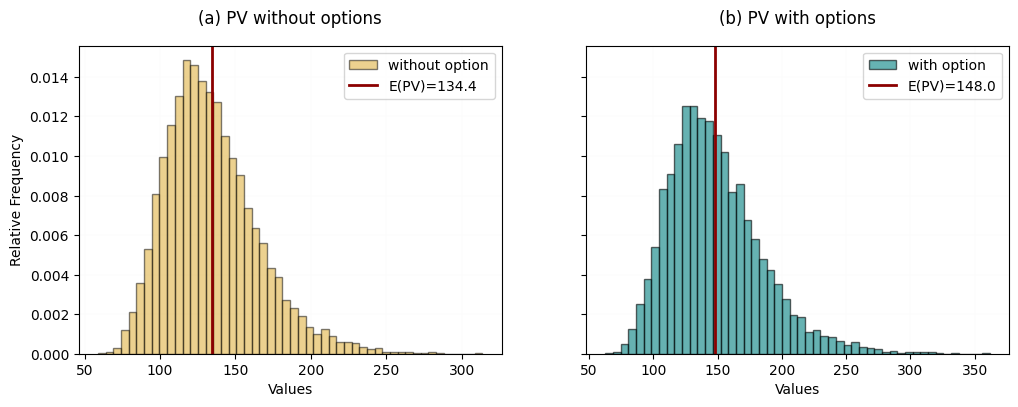

In [33]:
import numpy as np  # Certifique-se de importar numpy
import matplotlib.pyplot as plt

def plot_density_and_frequency(s1, s2, bins=50):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    # Sem opção
    axes[0].set_axisbelow(True)
    axes[0].hist(s1, bins=bins, density=True, color='goldenrod', alpha=0.5, edgecolor='black', label="without option")
    axes[0].axvline(x=np.mean(s1), color='darkred', linestyle='-', lw=2, label=f'E(PV)={np.mean(s1):.1f}')
    axes[0].set_xlabel("Values")
    axes[0].set_ylabel("Relative Frequency")
    #axes[0].set_xlim([0, 1650])
    #axes[0].set_ylim(0, 0.0030)
    axes[0].legend()
    axes[0].grid(lw=0.1, color="0.94")
    # Subtítulo
    #axes[0].text(0.5, -0.25, "(a) PV without options", ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title("(a) PV without options", loc='center', fontsize=12, pad=16)

    # Com opção
    axes[1].set_axisbelow(True)
    axes[1].hist(s2, bins=bins, density=True, color='teal', alpha=0.6, edgecolor='black', label="with option")
    axes[1].axvline(x=np.mean(s2), color='darkred', linestyle='-', lw=2, label=f'E(PV)={np.mean(s2):.1f}')
    axes[1].set_xlabel("Values")
    #axes[1].set_xlim([0, 1650])
    #axes[1].set_ylim(0, 0.0030)
    axes[1].legend()
    axes[1].grid(lw=0.1, color="0.94")
    # Subtítulo
    #axes[1].text(0.5, -0.25, "(b) PV with options", ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title("(b) PV with options", loc='center', fontsize=12, pad=16)


    # Salvar figura
    output_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\paper_com_Bratvold\sn-article-template\density_NPV_2_egg.eps"
    plt.savefig(output_path, format='eps', dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()


# Exemplo de uso
s1 = present_value(df1, dr)
s2 = present_value(df_cf_options, dr)
plot_density_and_frequency(s1, s2)

#####################################################################################################################

## Analysis

In [34]:
import pandas as pd

def count_option_occurrences(df_options):
    """
    Counts occurrences of 'buyout', 'continue', and 'divest' in each column of a DataFrame.

    Parameters:
    df_options (pd.DataFrame): DataFrame containing categorical values ('buyout', 'continue', 'divest').

    Returns:
    pd.DataFrame: DataFrame with counts of each option per column.
    """
    # Define the options to count
    options = ['buyout', 'continue', 'divest']
    
    # Count occurrences of each option in every column
    option_counts = {option: df_options.apply(lambda col: (col == option).sum()) for option in options}
    
    # Convert dictionary to DataFrame
    result_df = pd.DataFrame(option_counts)
    
    return result_df

count_option_occurrences(df_options).T

,0,1,2,3,4,5,6,7,8,9,10
buyout,0,10000,0,0,0,0,0,0,0,0,0
continue,0,0,10000,9998,9846,9273,7880,5512,2159,21,0
divest,0,0,0,2,152,573,1393,2368,3353,2138,21


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


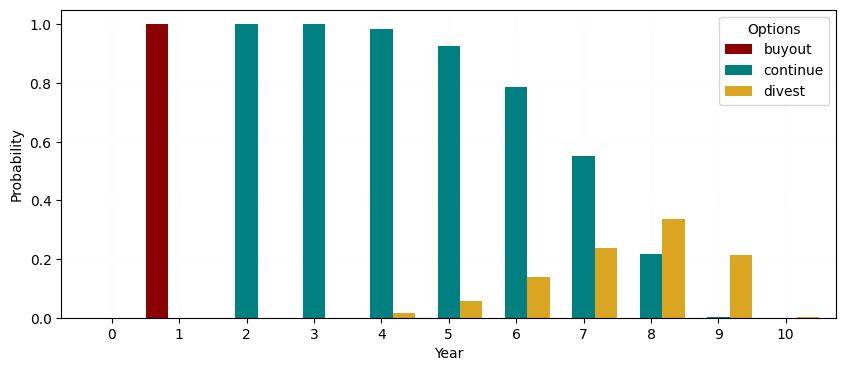

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados de exemplo

# Criando o DataFrame
df = pd.DataFrame(count_option_occurrences(df_options).T, index=["buyout", "continue", "divest"]).T
df_prob = df/trialno
# Plotando o gráfico de barras
cores = ['darkred', 'teal', 'goldenrod']
ax = df_prob.plot(kind='bar', figsize=(10, 4), width=1., color=cores)

# Configurações adicionais
plt.xlabel('Year')
plt.ylabel('Probability')
plt.xticks(rotation=0)  # Mantém os rótulos do eixo x na horizontal
plt.legend(title='Options')  # Legenda fora do gráfico
ax.set_axisbelow(True)
plt.grid(lw=0.1, color="0.94")
plt.ylim(0, 1.05)

# Salvar figura
output_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\paper_com_Bratvold\sn-article-template\options_prob_egg.eps"
plt.savefig(output_path, format='eps', dpi=300, bbox_inches='tight')

plt.show()
plt.close()

In [37]:
# LSM approach (regression used)
degree = 2
poly_type = 'laguerre'  # poly_type (str): Type of polynomial ('poly', 'hermite', 'legendre', 'chebyshev', 'jacobi', 'laguerre').

# The list of options must be written in the form of a dictionary with option label as the key, and option expense and cash flow reward as the value.
options = {'continue': [0, 0], 'buyout': [1, 25], 'divest': [0, 2.5]}

# Listas para armazenar os resultados
pv_single = []  # Cada option_times é [i]
pv_cumulative = []  # option_times é [1], [1,2], ..., [1,2,...,10]

# IMPORTANTE: Adapte para capturar a saída correta do seu notebook
for i in range(1, 11):
    # 1. Variação single
    option_times = [i]
    %run apply_options.ipynb  # Executa o notebook com option_times definido
    pv_single.append(pv)  # Substitua pelo nome da variável de saída
    
    # 2. Variação cumulativa
    option_times = list(range(1, i+1))
    %run apply_options.ipynb
    pv_cumulative.append(pv)

pv_single_fmt = [round(float(x), 1) for x in pv_single]
pv_cumulative_fmt = [round(float(x), 1) for x in pv_cumulative]

print("PV (single option_times):", pv_single_fmt)
print("PV (cumulative option_times):", pv_cumulative_fmt)

Options times:   0%|          | 0/1 [00:00<?, ?time/s]

Value of the initial investment: $20.0
PV of cash flows: $147.2
Value of the project with options (NPV): $127.2
Option value: $12.8


Options times:   0%|          | 0/1 [00:00<?, ?time/s]

Value of the initial investment: $20.0
PV of cash flows: $147.2
Value of the project with options (NPV): $127.2
Option value: $12.8


Options times:   0%|          | 0/1 [00:00<?, ?time/s]

...

Value of the initial investment: $20.0
PV of cash flows: $148.0
Value of the project with options (NPV): $128.0
Option value: $13.6


Options times:   0%|          | 0/1 [00:00<?, ?time/s]

Value of the initial investment: $20.0
PV of cash flows: $135.9
Value of the project with options (NPV): $115.9
Option value: $1.5


Options times:   0%|          | 0/10 [00:00<?, ?time/s]

Value of the initial investment: $20.0
PV of cash flows: $148.0
Value of the project with options (NPV): $128.0
Option value: $13.6
PV (single option_times): [147.2, 140.2, 137.6, 136.2, 135.4, 135.1, 135.1, 135.4, 135.9, 135.9]
PV (cumulative option_times): [147.2, 147.2, 147.2, 147.2, 147.3, 147.4, 147.5, 147.7, 148.0, 148.0]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


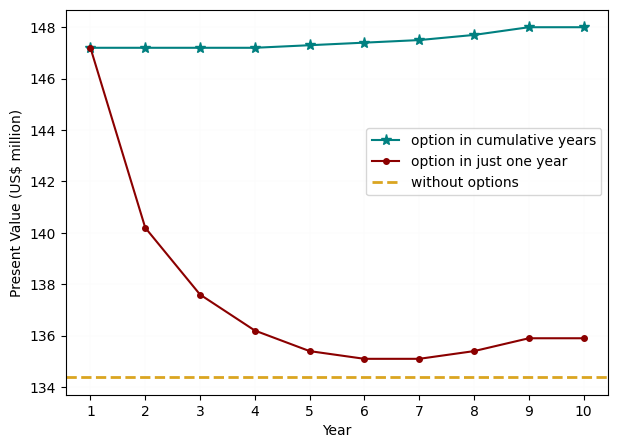

In [39]:
plt.figure(figsize=(7, 5))

plt.plot(np.arange(1, T+1), pv_cumulative_fmt, marker='*', ms=8, label='option in cumulative years', color='teal')
plt.plot(np.arange(1, T+1), pv_single_fmt, marker='.', ms=8, label='option in just one year', color='darkred')
plt.axhline(pv_without, color='goldenrod', linestyle='--', linewidth=2, label='without options')
#plt.text(x=3.5, y=pv_without + 1., s='PV without options', color='goldenrod', fontsize=10, ha='center')
plt.xlabel('Year')
plt.ylabel('Present Value (US$ million)')

plt.grid(lw=0.1, color="0.94")
plt.legend(loc='lower right', bbox_to_anchor=(1, 0.5))

# Garante que o eixo x vai mostrar exatamente os valores do array time
plt.xticks(ticks=np.arange(1, T+1), labels=[str(i) for i in np.arange(1, T+1)])

# Salvar figura
output_path = r"C:\Users\calva\OneDrive\Documentos\Doutorado\paper_com_Bratvold\sn-article-template\graph_options_egg.eps"
plt.savefig(output_path, format='eps', dpi=300, bbox_inches='tight')

plt.show()
plt.close()